%pip install re

In [7]:
import pandas as pd

# Load the Excel file
file_path = r"Z:\HTOC\Data_Analytics\Data\Threat Assessment Scores\Threat_Assessment_Scores.xlsx"
df = pd.read_excel(file_path)

# Display the first few rows
df

,Indicator,Last Observed,Indicator Type,Observation Yearly Count,ThreatConnect Rating,Observation Penalty Multiplier,Botnet Flag,False Positives,Partners,incidents/events,Threat Actor,CAL Score,ThreatConnect Score,HTOC Threat Score,Severity,Explanation
0,1.234.83.26,2026-02-14,Address,43,3,0.997644,0,0,NaN,NaN,NaN,180,469,134,low,[2026-03-16] Severity: low. VT score: 3. Top d...
1,101.168.57.163,2026-02-14,Address,2,3,0.999890,0,0,NaN,Incident:INC9407577,NaN,180,590,389,medium,[2026-03-16] Severity: medium. VT score: 11. T...
2,101.71.130.99,2026-03-03,Address,139,3,0.992384,0,0,"CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS",Incident:INC9270850,NaN,180,346,464,medium,[2026-03-16] Severity: medium. VT score: 11. T...
3,103.114.96.246,2026-02-26,Address,41,1,0.997753,1,0,"CMS, DHA, NIH, OS, VA",NaN,Mr Hamza Group,170,224,130,low,[2026-03-16] Severity: low. VT score: 1. Top d...
4,103.120.116.162,2026-03-16,Address,48,3,0.997370,0,0,"CMS, DHA, FDA, HRSA, IHS, NIH, OS, VA",Incident:INC9385644,NaN,740,870,364,medium,[2026-03-16] Severity: medium. VT score: 6. To...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291,198.199.103.243,2026-01-16,Address,1,0,0.999945,1,0,VA,Incident:6755399478001848,NaN,180,368,41,low,Severity: low. VT score: 0. Top drivers: Incid...
2292,w-2@doculivery.com,2026-03-04,EmailAddress,2,4,0.999890,1,0,HHS,Incident:547380,NaN,170,224,29,low,[2026-03-06] Severity: low. VT score not avail...
2293,link.edgepilot.com,2026-03-05,Host,74,1,0.995945,0,0,"CMS, NIH",NaN,NaN,180,229,28,low,[2026-03-06] Severity: low. VT score not avail...
2294,52.87.206.242,2026-01-08,Address,1,1,0.999945,1,0,IHS,NaN,NaN,170,224,27,low,Severity: low. VT score: 0. Top drivers: TC ra...


### Threat actor / indicator / HTOC Threat Score analysis

This section explores how **threat actors**, their **associated indicators**, and their **HTOC Threat Scores** relate to each other.

Goals:
- Summarize indicators per threat actor (counts, distinct indicators, indicator types).
- Summarize HTOC Threat Scores per threat actor (mean/median/max).
- Highlight the highest‑risk threat actors and their key indicators.

Mean: 293.226
Std dev: 147.573
Skewness: 0.336


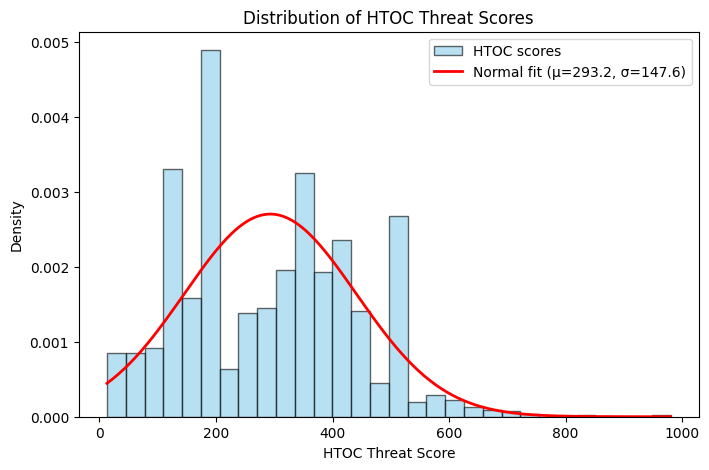

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# HTOC Threat Score data
scores = df["HTOC Threat Score"].dropna()

# Basic stats
mu = scores.mean()
sigma = scores.std()
skewness = scores.skew()  # Pearson moment skewness


"""
If |skew| < 0.5 → Mean is safe

If |skew| > 0.5 → Median is safer

If |skew| > 1 → Definitely use median or transform
"""

print(f"Mean: {mu:.3f}")
print(f"Std dev: {sigma:.3f}")
print(f"Skewness: {skewness:.3f}")

# Plot histogram + normal fit
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(scores, bins=30, density=True, alpha=0.6, color="skyblue", edgecolor="black", label="HTOC scores")

x = np.linspace(scores.min(), scores.max(), 200)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
ax.plot(x, pdf, "r-", lw=2, label=f"Normal fit (μ={mu:.1f}, σ={sigma:.1f})")

ax.set_title("Distribution of HTOC Threat Scores")
ax.set_xlabel("HTOC Threat Score")
ax.set_ylabel("Density")
ax.legend()
plt.show()

Columns in df:
['Indicator', 'Last Observed', 'Indicator Type', 'Observation Yearly Count', 'ThreatConnect Rating', 'Observation Penalty Multiplier', 'Botnet Flag', 'False Positives', 'Partners', 'incidents/events', 'Threat Actor', 'CAL Score', 'ThreatConnect Score', 'HTOC Threat Score', 'Severity', 'Explanation']

Guessed columns:
  Indicator column: Indicator
  Threat actor column: Threat Actor
  HTOC Threat Score column: HTOC Threat Score

Top 15 threat actors by mean HTOC Threat Score:


,Threat Actor,indicator_count,unique_indicators,mean_score,median_score,max_score,min_score,severity_bucket_mean
5,Crimson Collective,1,1,820.000000,820.0,820,820,critical
45,UNC6395,1,1,820.000000,820.0,820,820,critical
35,UNC3973,1,1,738.000000,738.0,738,738,high
2,Charming Kitten,1,1,713.000000,713.0,713,713,high
20,Play Ransomware Group,1,1,713.000000,713.0,713,713,high
9,FIN4,1,1,684.000000,684.0,684,684,high
25,ShadowSyndicate,1,1,675.000000,675.0,675,675,high
30,Strawberry Tempest,1,1,660.000000,660.0,660,660,high
31,UNC2447,1,1,660.000000,660.0,660,660,high
48,Void Blizzard,1,1,632.000000,632.0,632,632,high



Top threat actors by number of indicators:


,Threat Actor,indicator_count,unique_indicators,mean_score,median_score,max_score,min_score,severity_bucket_mean
41,UNC5537,135,135,350.474074,354.0,662,144,medium
19,Onyx Sleet,24,24,305.666667,365.0,456,69,medium
4,Cozy Bear,24,24,396.625000,388.0,861,85,medium
22,Richochet Chollima,24,24,305.666667,365.0,456,69,medium
28,Stardust Chollima,24,24,305.666667,365.0,456,69,medium
6,Diamond Sleet,23,23,301.739130,334.0,456,69,medium
7,Emerald Sleet,23,23,310.565217,396.0,456,69,medium
16,Mr Hamza Group,23,23,225.521739,171.0,499,104,medium
11,Fancy Bear,23,23,407.608696,451.0,861,85,medium
23,Scattered Spider,21,21,491.952381,481.0,820,193,medium


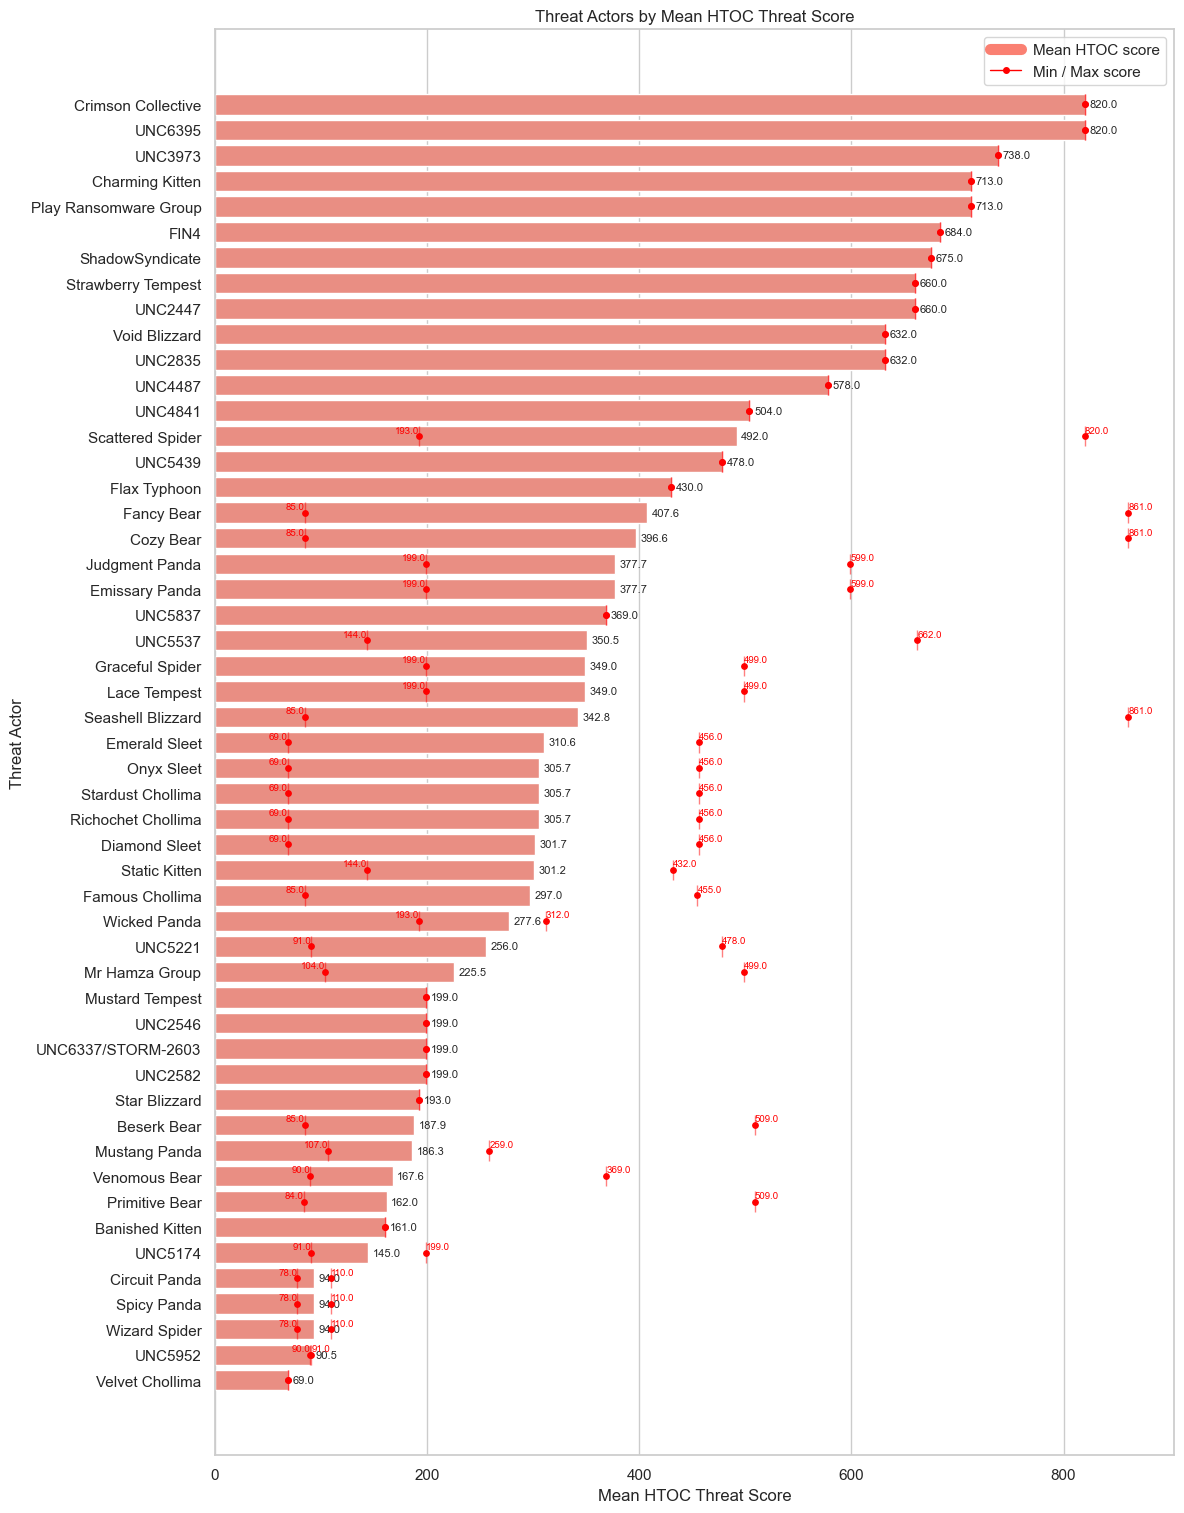

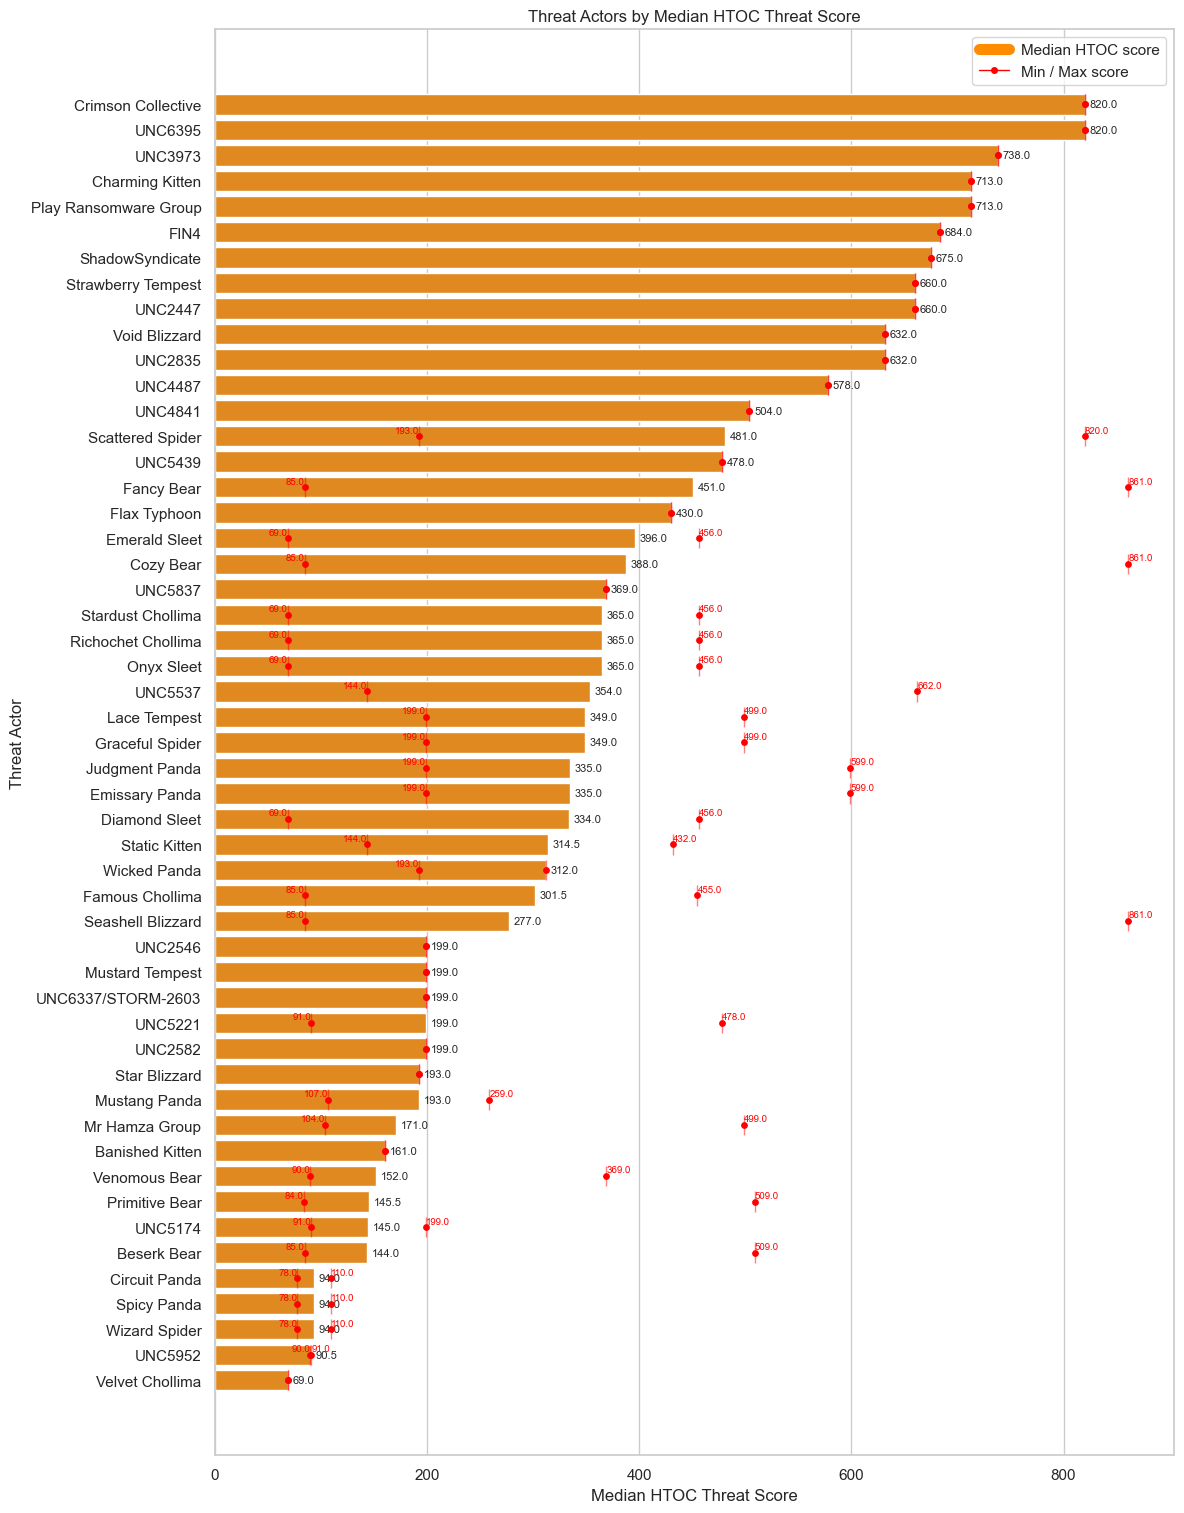

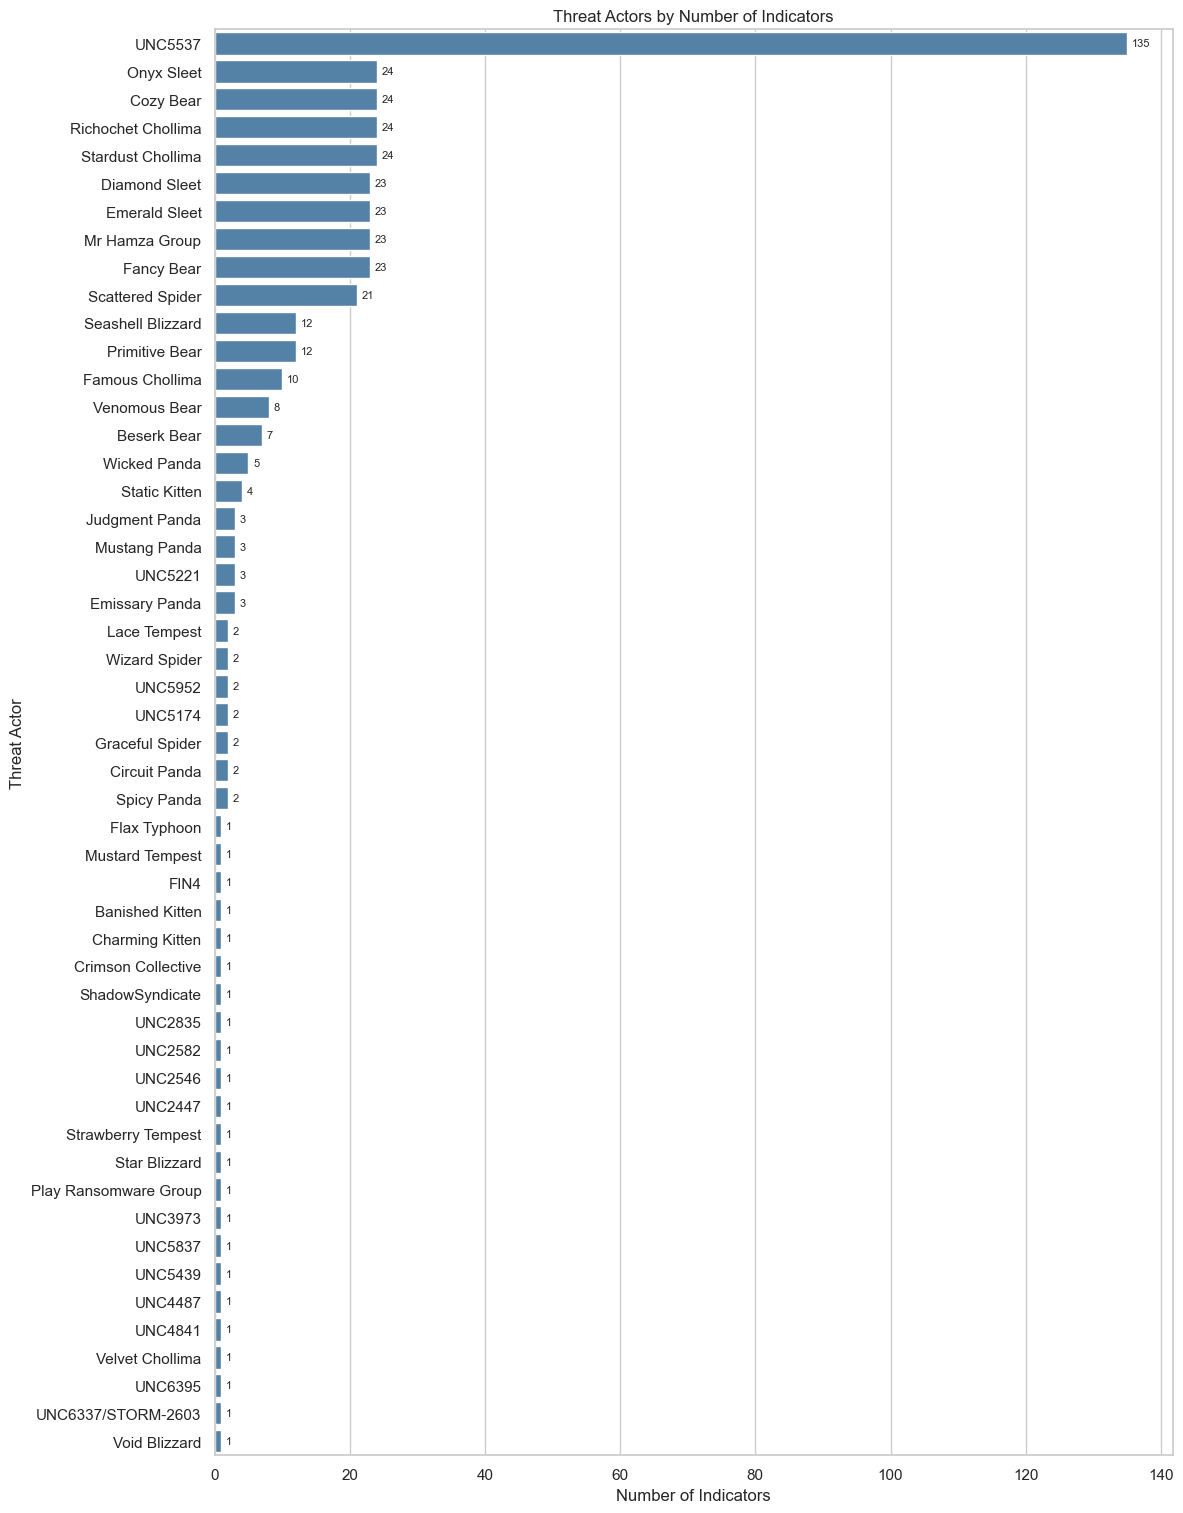

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Severity bucket definitions (from V3 notebook)
scoring_bins = [0, 200, 500, 800, 1001]
label_bins = ["low", "medium", "high", "critical"]

# Make sure plots render nicely
sns.set(style="whitegrid")

print("Columns in df:")
print(df.columns.tolist())

# Try to automatically identify key columns
cols_lower = {c.lower(): c for c in df.columns}

# Likely indicator column
indicator_col = None
for key in ["indicator", "ioc", "indicator value", "observable"]:
    for c in df.columns:
        if key in c.lower():
            indicator_col = c
            break
    if indicator_col:
        break

# Likely threat actor column
threat_actor_col = None
for key in ["threat actor", "actor", "group", "campaign"]:
    for c in df.columns:
        if key in c.lower():
            threat_actor_col = c
            break
    if threat_actor_col:
        break

# Likely HTOC Threat Score column
score_col = None
for key in ["htoc threat score", "threat score", "score"]:
    for c in df.columns:
        if key in c.lower():
            score_col = c
            break
    if score_col:
        break

print("\nGuessed columns:")
print(f"  Indicator column: {indicator_col}")
print(f"  Threat actor column: {threat_actor_col}")
print(f"  HTOC Threat Score column: {score_col}")

if not threat_actor_col or not score_col:
    raise ValueError(
        "Could not reliably identify threat actor or HTOC Threat Score columns. "
        "Please adjust `threat_actor_col` and `score_col` manually in this cell."
    )

# Work on a filtered copy with non-null threat actor & score
work_df = df.copy()
work_df = work_df[(work_df[threat_actor_col].notna()) & (work_df[score_col].notna())]

# Split rows that contain multiple threat actors (comma-separated)
work_df = work_df.copy()
work_df[threat_actor_col] = work_df[threat_actor_col].astype(str).str.split(r"\s*,\s*")
work_df = work_df.explode(threat_actor_col)

# Basic per-actor aggregation (now each row has exactly one threat actor)
indicator_col = indicator_col or "Indicator"  # fall back to the visible column name

agg = work_df.groupby(threat_actor_col).agg(
    indicator_count=(indicator_col, "count"),
    unique_indicators=(indicator_col, pd.Series.nunique),
    mean_score=(score_col, "mean"),
    median_score=(score_col, "median"),
    max_score=(score_col, "max"),
    min_score=(score_col, "min"),
).reset_index()

# Derive severity bucket for mean score
agg["severity_bucket_mean"] = pd.cut(
    agg["mean_score"],
    bins=scoring_bins,
    labels=label_bins,
    right=False,
    include_lowest=True,
)

# Sort by mean score descending
agg_sorted_by_score = agg.sort_values("mean_score", ascending=False)

print("\nTop 15 threat actors by mean HTOC Threat Score:")
display(agg_sorted_by_score.head(15))

print("\nTop threat actors by number of indicators:")
agg_sorted_by_indicators = agg.sort_values("indicator_count", ascending=False)
display(agg_sorted_by_indicators)

# --- Visuals ---

from matplotlib.lines import Line2D

# Barplot: all actors by mean score
subset = agg_sorted_by_score
plt.figure(figsize=(12, max(6, 0.3 * len(subset))))
ax = sns.barplot(
    data=subset,
    x="mean_score",
    y=threat_actor_col,
    color="salmon",
)

# Add data labels (mean)
for p in ax.patches:
    value = p.get_width()
    ax.text(
        value + (ax.get_xlim()[1] * 0.005),
        p.get_y() + p.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=8,
    )

# Add min–max markers and labels for each bar (using agg[min_score], agg[max_score])
for p in ax.patches:
    y_center = p.get_y() + p.get_height() / 2
    tick_positions = ax.get_yticks()
    tick_labels = [t.get_text() for t in ax.get_yticklabels()]
    if not len(tick_positions) or not len(tick_labels):
        continue

    closest_idx = min(
        range(len(tick_positions)),
        key=lambda i: abs(tick_positions[i] - y_center),
    )
    actor_name = tick_labels[closest_idx]
    row = agg.loc[agg[threat_actor_col] == actor_name]
    if row.empty:
        continue

    x_min = float(row["min_score"].iloc[0])
    x_max = float(row["max_score"].iloc[0])

    # subtle vertical lines at min & max
    ax.vlines(x_min, p.get_y(), p.get_y() + p.get_height(), colors="red", linewidth=1, alpha=0.5)
    ax.vlines(x_max, p.get_y(), p.get_y() + p.get_height(), colors="red", linewidth=1, alpha=0.5)

    # point markers at min & max
    ax.scatter(x_min, y_center, color="red", s=15, zorder=4)
    ax.scatter(x_max, y_center, color="red", s=15, zorder=4)

    # label min/max only if different from mean
    mean_val = p.get_width()
    eps = 1e-6

    if abs(x_min - mean_val) > eps:
        ax.text(
            x_min,
            y_center - p.get_height() * 0.3,
            f"{x_min:.1f}",
            ha="right",
            va="center",
            fontsize=7,
            color="red",
        )

    if abs(x_max - mean_val) > eps:
        ax.text(
            x_max,
            y_center - p.get_height() * 0.3,
            f"{x_max:.1f}",
            ha="left",
            va="center",
            fontsize=7,
            color="red",
        )

plt.title("Threat Actors by Mean HTOC Threat Score")
plt.xlabel("Mean HTOC Threat Score")
plt.ylabel("Threat Actor")

mean_handle = Line2D([0], [0], color="salmon", lw=8, label="Mean HTOC score")
minmax_handle = Line2D(
    [0],
    [0],
    color="red",
    lw=1,
    marker="o",
    markersize=4,
    linestyle="-",
    label="Min / Max score",
)
ax.legend(handles=[mean_handle, minmax_handle], loc="best")

plt.tight_layout()
plt.show()

# Barplot: all actors by median score
subset_med = agg.sort_values("median_score", ascending=False)
plt.figure(figsize=(12, max(6, 0.3 * len(subset_med))))
ax = sns.barplot(
    data=subset_med,
    x="median_score",
    y=threat_actor_col,
    color="darkorange",
)

# Add data labels (median)
for p in ax.patches:
    value = p.get_width()
    ax.text(
        value + (ax.get_xlim()[1] * 0.005),
        p.get_y() + p.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=8,
    )

# Add min–max markers and labels for each bar (using agg[min_score], agg[max_score])
for p in ax.patches:
    y_center = p.get_y() + p.get_height() / 2
    tick_positions = ax.get_yticks()
    tick_labels = [t.get_text() for t in ax.get_yticklabels()]
    if not len(tick_positions) or not len(tick_labels):
        continue

    closest_idx = min(
        range(len(tick_positions)),
        key=lambda i: abs(tick_positions[i] - y_center),
    )
    actor_name = tick_labels[closest_idx]
    row = agg.loc[agg[threat_actor_col] == actor_name]
    if row.empty:
        continue

    x_min = float(row["min_score"].iloc[0])
    x_max = float(row["max_score"].iloc[0])

    ax.vlines(x_min, p.get_y(), p.get_y() + p.get_height(), colors="red", linewidth=1, alpha=0.5)
    ax.vlines(x_max, p.get_y(), p.get_y() + p.get_height(), colors="red", linewidth=1, alpha=0.5)

    ax.scatter(x_min, y_center, color="red", s=15, zorder=4)
    ax.scatter(x_max, y_center, color="red", s=15, zorder=4)

    # label min/max only if different from median
    median_val = p.get_width()
    eps = 1e-6

    if abs(x_min - median_val) > eps:
        ax.text(
            x_min,
            y_center - p.get_height() * 0.3,
            f"{x_min:.1f}",
            ha="right",
            va="center",
            fontsize=7,
            color="red",
        )

    if abs(x_max - median_val) > eps:
        ax.text(
            x_max,
            y_center - p.get_height() * 0.3,
            f"{x_max:.1f}",
            ha="left",
            va="center",
            fontsize=7,
            color="red",
        )

plt.title("Threat Actors by Median HTOC Threat Score")
plt.xlabel("Median HTOC Threat Score")
plt.ylabel("Threat Actor")

median_handle = Line2D([0], [0], color="darkorange", lw=8, label="Median HTOC score")
minmax_handle = Line2D(
    [0],
    [0],
    color="red",
    lw=1,
    marker="o",
    markersize=4,
    linestyle="-",
    label="Min / Max score",
)
ax.legend(handles=[median_handle, minmax_handle], loc="best")

plt.tight_layout()
plt.show()

# Barplot: all actors by indicator count
subset2 = agg_sorted_by_indicators
plt.figure(figsize=(12, max(6, 0.3 * len(subset2))))
ax = sns.barplot(
    data=subset2,
    x="indicator_count",
    y=threat_actor_col,
    color="steelblue",
)

# Add data labels
for p in ax.patches:
    value = p.get_width()
    ax.text(
        value + (ax.get_xlim()[1] * 0.005),
        p.get_y() + p.get_height() / 2,
        f"{int(value)}",
        va="center",
        ha="left",
        fontsize=8,
    )

plt.title("Threat Actors by Number of Indicators")
plt.xlabel("Number of Indicators")
plt.ylabel("Threat Actor")
plt.tight_layout()
plt.show()

All threat actors with unique partners:


,Threat Actor,unique_partner_count,partner_list
18,Mustard Tempest,10,"CDC, CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS, VA"
6,Diamond Sleet,10,"CDC, CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS, VA"
4,Cozy Bear,10,"CDC, CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS, VA"
11,Fancy Bear,10,"CDC, CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS, VA"
41,UNC5537,10,"CDC, CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS, VA"
40,UNC5439,10,"CDC, CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS, VA"
28,Stardust Chollima,10,"CDC, CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS, VA"
23,Scattered Spider,10,"CDC, CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS, VA"
24,Seashell Blizzard,10,"CDC, CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS, VA"
22,Richochet Chollima,10,"CDC, CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS, VA"


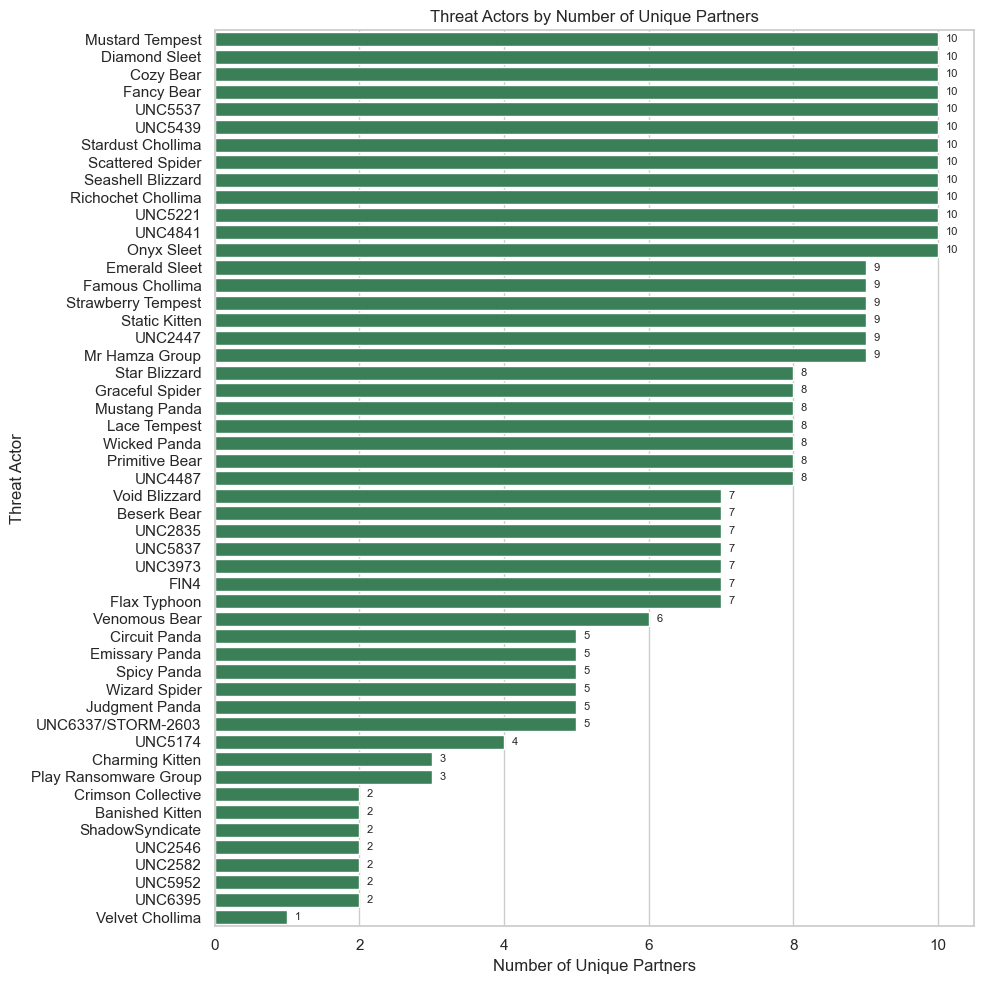

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ta_col = "Threat Actor"

# Start from the base df, keep only needed columns
ta_partners = (
    df[[ta_col, "Partners"]]
    .dropna(subset=[ta_col])  # need a threat actor
    .copy()
)

# Handle multiple threat actors in a cell (comma‑separated)
ta_partners[ta_col] = ta_partners[ta_col].astype(str).str.split(r"\s*,\s*")
ta_partners = ta_partners.explode(ta_col)

# Handle multiple partners in a cell (comma‑separated)
ta_partners["Partners"] = ta_partners["Partners"].fillna("").astype(str)
ta_partners["Partners"] = ta_partners["Partners"].str.split(r"\s*,\s*")
ta_partners = ta_partners.explode("Partners")

# Drop blank partner entries
ta_partners = ta_partners[ta_partners["Partners"].str.len() > 0]

# Aggregate per threat actor
partner_summary = (
    ta_partners.groupby(ta_col)["Partners"]
    .agg(
        unique_partner_count=lambda x: x.nunique(),
        partner_list=lambda x: ", ".join(sorted(set(x))),
    )
    .reset_index()
    .sort_values("unique_partner_count", ascending=False)
)

print("All threat actors with unique partners:")
display(partner_summary)

top10 = partner_summary

plt.figure(figsize=(10, 10))
ax = sns.barplot(
    data=top10,
    x="unique_partner_count",
    y=ta_col,
    color="seagreen",
)

for p in ax.patches:
    value = p.get_width()
    ax.text(
        value + (ax.get_xlim()[1] * 0.01),
        p.get_y() + p.get_height() / 2,
        f"{int(value)}",
        va="center",
        ha="left",
        fontsize=8,
    )

plt.title("Threat Actors by Number of Unique Partners")
plt.xlabel("Number of Unique Partners")
plt.ylabel("Threat Actor")
plt.tight_layout()
plt.show()